In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("winemag-data_first150k.csv")
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude


In [6]:
df.shape

(150930, 11)

<Axes: xlabel='country'>

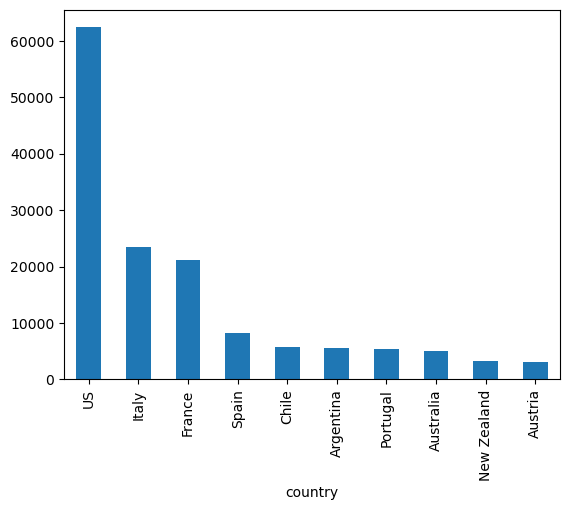

In [8]:
df["country"].value_counts().head(10).plot.bar()

<Axes: xlabel='points', ylabel='price'>

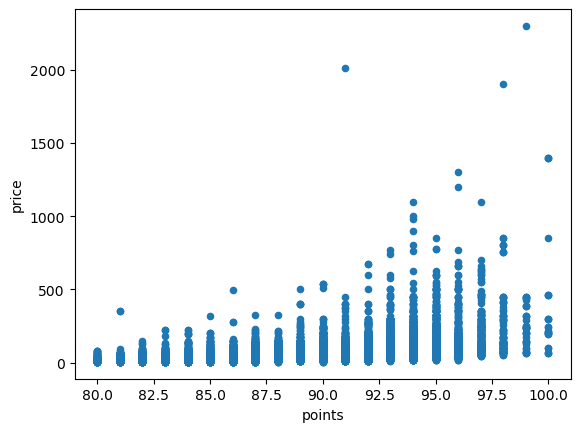

In [9]:
df.plot.scatter(x="points",y="price")

In [ ]:
df.plot.hexbin(x="price",y="points")

<Axes: xlabel='price', ylabel='points'>

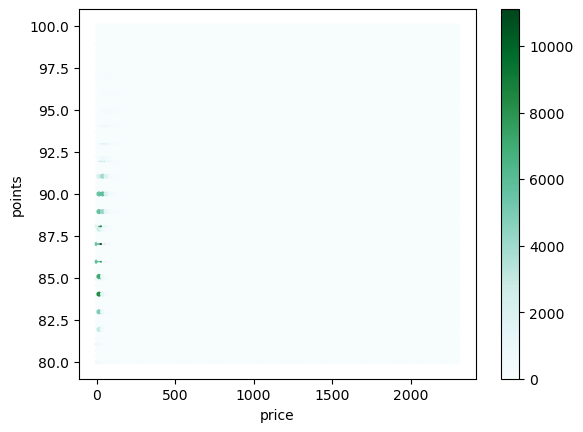

In [11]:
df.plot.hexbin(x="price",y="points")

Text(0.5, 1.0, 'Count the wine-points')

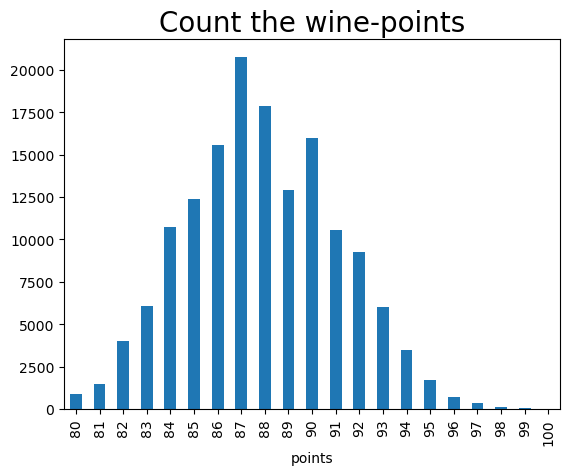

In [12]:
dx=df["points"].value_counts().sort_index().plot.bar()
dx.set_title("Count the wine-points",fontsize=20)

<Axes: xlabel='count', ylabel='country'>

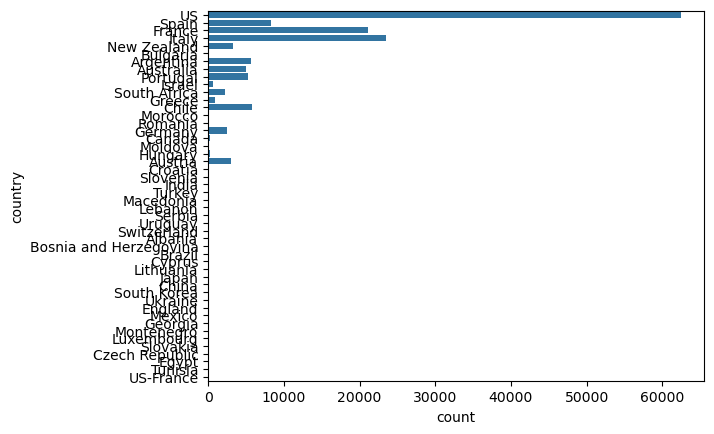

In [13]:
sns.countplot(df["country"])

<Axes: xlabel='price', ylabel='Density'>

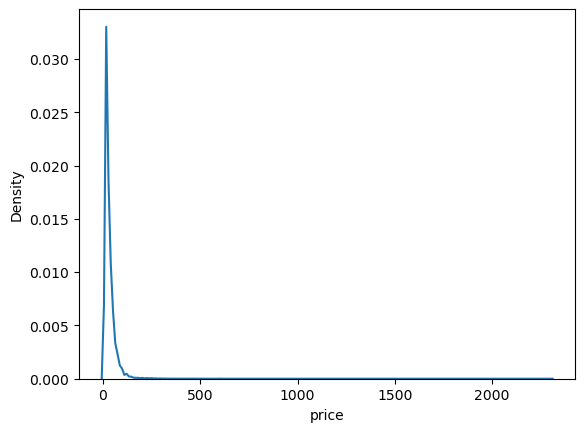

In [14]:
sns.kdeplot(df["price"])

<Axes: xlabel='variety', ylabel='points'>

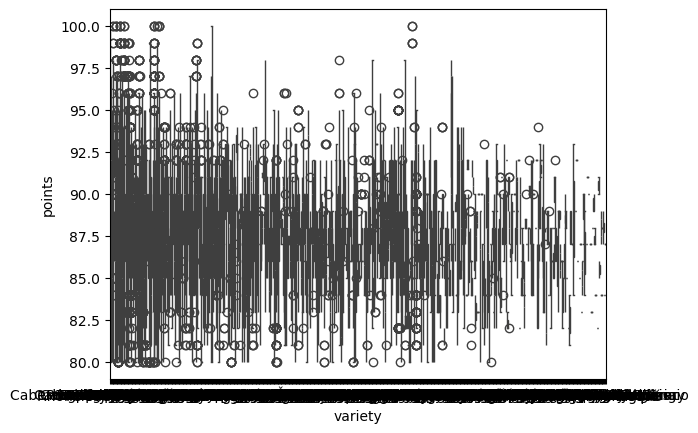

In [18]:
sns.boxplot(x="variety",y="points",data=df)

<Axes: xlabel='country', ylabel='count'>

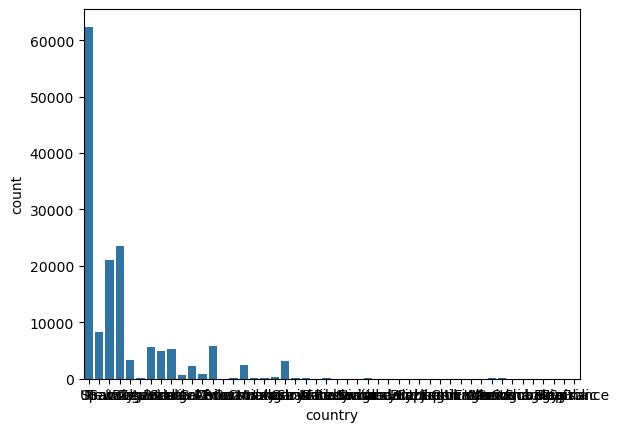

In [19]:
sns.countplot(x="country",data=df)

In [ ]:
sns.pairplot(df)

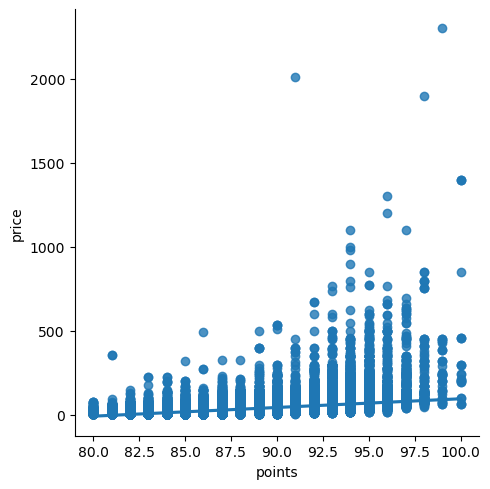

In [25]:
sns.lmplot(y="price",x="points",data=df)

In [26]:
df.groupby('country')["price"].mean().sort_values(ascending=False).head(10)

country
US-France     50.000000
England       47.500000
France        45.619885
Hungary       44.204348
Luxembourg    40.666667
Germany       39.011078
Italy         37.547913
Canada        34.628866
US            33.653808
Israel        31.304918
Name: price, dtype: float64

In [27]:
df['points'].mean()

np.float64(87.8884184721394)

In [28]:
df["variety"].value_counts().head(10)

variety
Chardonnay                  14482
Pinot Noir                  14291
Cabernet Sauvignon          12800
Red Blend                   10062
Bordeaux-style Red Blend     7347
Sauvignon Blanc              6320
Syrah                        5825
Riesling                     5524
Merlot                       5070
Zinfandel                    3799
Name: count, dtype: int64

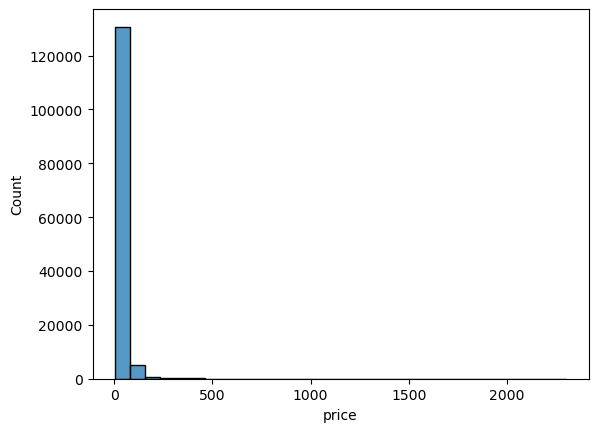

In [30]:
sns.histplot(df['price'],bins=30)
plt.show()

In [31]:
df.sort_values("price",ascending=False)[['country','variety','price']].head(10)

,country,variety,price
34920,France,Bordeaux-style Red Blend,2300.0
13318,US,Chardonnay,2013.0
34922,France,Bordeaux-style Red Blend,1900.0
26296,France,Chardonnay,1400.0
51886,France,Chardonnay,1400.0
83536,France,Chardonnay,1400.0
34939,France,Bordeaux-style Red Blend,1300.0
34942,France,Bordeaux-style Red Blend,1200.0
34927,France,Bordeaux-style Red Blend,1100.0
10651,Austria,Grüner Veltliner,1100.0


In [32]:
df[['price','points']].corr()

,price,points
price,1.000000,0.459863
points,0.459863,1.000000


In [33]:
df.groupby('variety')['price'].mean().sort_values(ascending=False).head(10)

variety
Cabernet-Shiraz    150.000000
Muscadel           141.300000
Mazuelo             98.500000
Tinto Fino          83.120000
Mission             82.571429
Tokay               82.117647
Carignan-Syrah      80.000000
Champagne Blend     78.627119
Debit               72.333333
Picolit             71.869565
Name: price, dtype: float64

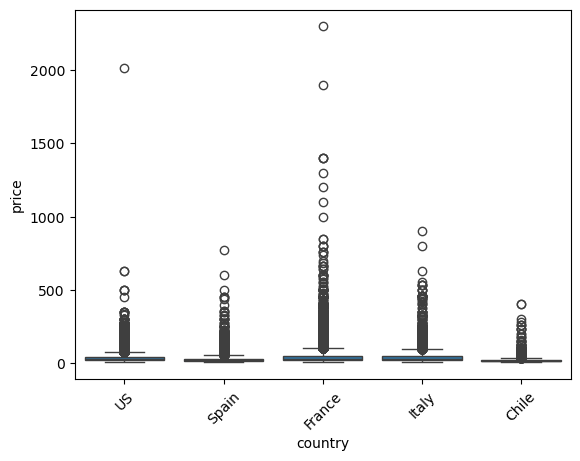

In [34]:
top_countries=df["country"].value_counts().head(5).index
sns.boxplot(x="country",y="price",data=df[df['country'].isin(top_countries)])
plt.xticks(rotation=45)
plt.show()

In [35]:
df[df['points']>95]

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
2145,2145,France,"Full of ripe fruit, opulent and concentrated, ...",NaN,100,848.0,Bordeaux,Pessac-Léognan,NaN,Bordeaux-style White Blend,Château Haut-Brion
...,...,...,...,...,...,...,...,...,...,...,...
148047,148047,US,The most complete and compelling of Diamond Cr...,Red Rock Terrace,97,175.0,California,Napa Valley,Napa,Cabernet Sauvignon,Diamond Creek
148048,148048,US,This shows winemaker Greg LaFollette's master ...,30th Anniversary Cuvee,96,45.0,California,Russian River Valley,Sonoma,Pinot Noir,De Loach
149172,149172,France,"This is a splendid wine. Yes, it is more power...",NaN,97,345.0,Bordeaux,Pauillac,NaN,Bordeaux-style Red Blend,Château Lafite Rothschild
149173,149173,France,This may be from the exceptional vintage of 20...,NaN,96,360.0,Bordeaux,Margaux,NaN,Bordeaux-style Red Blend,Château Margaux


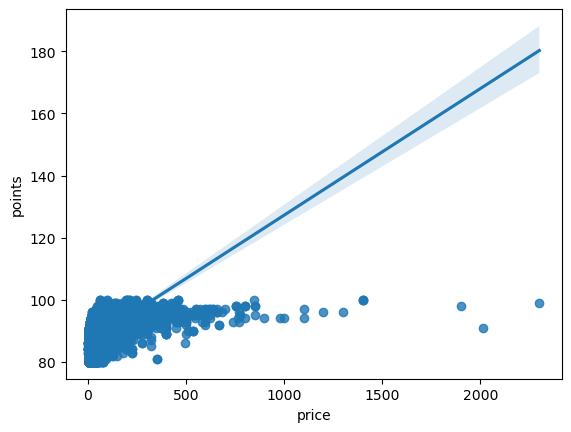

In [36]:
sns.regplot(x='price',y='points',data=df)
plt.show()

In [37]:
df.isnull().sum()

Unnamed: 0         0
country            5
description        0
designation    45735
points             0
price          13695
province           5
region_1       25060
region_2       89977
variety            0
winery             0
dtype: int64

In [38]:
df_clean_price=df.dropna(subset=['price'])

In [40]:
df_clean_price['price'].isnull().sum()

np.int64(0)

In [41]:
avg_rating=df['points'].mean()
df[df['points']>avg_rating].shape[0]

79002

In [42]:
df["ratio"]=df['points']/df['price']
df.groupby('country')['ratio'].mean().sort_values(ascending=False).head(10)

country
Lithuania                 8.425000
Bulgaria                  8.369827
Montenegro                8.200000
Romania                   7.709988
India                     6.734135
Bosnia and Herzegovina    6.660256
Moldova                   6.645491
Ukraine                   6.507692
South Korea               6.244318
Chile                     6.065113
Name: ratio, dtype: float64